In [34]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt

In [35]:
def format_ml(df):
    """
    Transforms a wide-format crime dataset into a long format with lag features for ML.
    """
    
    # 1. Isolate static features
    static_features = [
        'edge_id', 'u', 'u_lat', 'u_lng', 'v', 'v_lat', 'v_lng', 
        'key', 'name', 'highway', 'length'
    ]
    df_static = df[static_features].copy()

    # 2. Isolating time series
    time_cols = [col for col in df.columns if pd.Series(col).str.contains(r'\d{4}_\d{2}$').any()]
    df_time = df[['edge_id'] + time_cols].copy()

    # 3. Condensing all time columns into 'metric' and 'value'
    df_melted = df_time.melt(id_vars='edge_id', var_name='metric_month', value_name='value')

    # 4. Split the melted column into a 'metric' and a 'year_month'
    # e.g., splits 'crime_count_2023_06' -> 'crime_count' and '2023_06'
    extract_regex = r'^(?P<metric>.*)_(?P<year_month>\d{4}_\d{2})$'
    df_melted[['metric', 'year_month']] = df_melted['metric_month'].str.extract(extract_regex)
    df_melted = df_melted.drop(columns=['metric_month'])

    # 5. Pivot: Push the metrics back into their own distinct columns
    df_long = df_melted.pivot(
        index=['edge_id', 'year_month'], 
        columns='metric', 
        values='value'
    ).reset_index()

    # 6. Sort chronologically
    df_long = df_long.sort_values(by=['edge_id', 'year_month'])

    # 7. Engineer Lag Features (1, 2 and 3 months)
    lags = [1, 2, 3]
    metrics_to_lag = ['crime_count', 'crime_severity_sum', 'stop_search_count']

    for metric in metrics_to_lag:
        for lag in lags:
            # Groupby ensures a street only looks at its own history, not the street above it
            df_long[f'{metric}_lag_{lag}'] = df_long.groupby('edge_id')[metric].shift(lag)

    # 8. Drop rows with NaNs caused by the shift (first 3 months)
    df_long = df_long.dropna(subset=[f'crime_count_lag_{lag}' for lag in lags]).reset_index(drop=True)

    # 9. Merge the static street metadata back in
    final_df = pd.merge(df_long, df_static, on='edge_id', how='left')

    # 10. Rename current month metrics to 'target'
    final_df = final_df.rename(columns={
        'crime_count': 'target_crime_count',
        'crime_severity_sum': 'target_crime_severity',
        'stop_search_count': 'target_stop_search'
    })

    return final_df



In [36]:
def train_crime_model(ml_ready_df):
    """
    Trains the simple XGBoost ML model
    """
    # 1. Define the chronological cutoff (e.g., hold out the last 3 months for testing)
    # Based on your data ending in 2026_05, let's test on Spring 2026
    cutoff_month = '2026_03'
    
    # 2. Split into Train (Past) and Test (Future)
    train_df = ml_ready_df[ml_ready_df['year_month'] < cutoff_month].copy()
    test_df = ml_ready_df[ml_ready_df['year_month'] >= cutoff_month].copy()
    
    print(f"Training on {len(train_df)} records (Before {cutoff_month})")
    print(f"Testing on {len(test_df)} records ({cutoff_month} onwards)")

    # 3. Define the Target (y)
    target_col = 'target_crime_count'
    
    # 4. Define Features (X)
    # CRITICAL: We must drop identifiers, metadata strings, and concurrent targets
    cols_to_drop = [
        'edge_id', 'year_month', 'name', 'u', 'v', 'key', # Drop identifiers
        'target_crime_count', 'target_crime_severity', 'target_stop_search' # Drop ALL concurrent targets
    ]
    
    # Optional: Convert 'highway' (categorical string) to a Pandas category dtype 
    # so XGBoost can handle it natively without one-hot encoding.
    train_df['highway'] = train_df['highway'].astype('category')
    test_df['highway'] = test_df['highway'].astype('category')
    
    X_train = train_df.drop(columns=cols_to_drop)
    y_train = train_df[target_col]
    
    X_test = test_df.drop(columns=cols_to_drop)
    y_test = test_df[target_col]

    # 5. Initialize XGBoost Regressor
    # early_stopping_rounds is now defined HERE in newer XGBoost versions
    model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        enable_categorical=True,
        random_state=42,
        early_stopping_rounds=50  # <--- Moved here
    )

    # 6. Train the model
    print("Training XGBoost...")
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=50 # Print progress every 50 trees
    )

    # 7. Evaluate the predictions
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    print(f"\nMean Absolute Error (MAE): {mae:.2f} crimes per street")
    
    return model, X_train.columns



In [37]:
def feature_importance(model, X_train):
    """
    Extracts feature importance and displays in a bar chart.
    """
    # 1. Visual Plot: Using XGBoost's built-in plotter
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # We use importance_type='gain' because it measures predictive power
    xgb.plot_importance(
        model, 
        importance_type='gain', 
        max_num_features=15, # Only show the top 15 features
        ax=ax, 
        height=0.5,
        color='steelblue'
    )
    plt.title("Top 15 Most Predictive Features (by Information Gain)")
    plt.show()

    # 2. Raw Data: Extracting into a Pandas DataFrame
    importance_dict = model.get_booster().get_score(importance_type='gain')
    
    importance_df = pd.DataFrame({
        'Feature': list(importance_dict.keys()),
        'Gain': list(importance_dict.values())
    })
    
    # Sort from most to least important
    importance_df = importance_df.sort_values(by='Gain', ascending=False).reset_index(drop=True)
    
    print("\nFeature Importance Rankings:")
    print(importance_df.head(15))
    
    return importance_df

In [38]:

def predict_and_map_to_nodes(ml_ready_df, model, feature_columns, latest_month='2026_05'):
    """
    Predicts crime for the next month, calculates safety cost, and maps to OSM nodes.
    """
    # If a full DataFrame was passed instead of a list of columns, extract the column names
    if isinstance(feature_columns, pd.DataFrame):
        feature_columns = feature_columns.columns.tolist()
    elif hasattr(feature_columns, 'tolist'):
        feature_columns = feature_columns.tolist()
    
    # ==========================================
    # 1. Prepare Future Data (Shift Lags Forward)
    # ==========================================
    latest_data = ml_ready_df[ml_ready_df['year_month'] == latest_month].copy()
    future_data = latest_data.copy()
    
    # Shift the lags forward by 1 month
    future_data['crime_count_lag_1'] = latest_data['target_crime_count']
    future_data['crime_count_lag_2'] = latest_data['crime_count_lag_1']
    future_data['crime_count_lag_3'] = latest_data['crime_count_lag_2']
    
    future_data['crime_severity_sum_lag_1'] = latest_data['target_crime_severity']
    future_data['crime_severity_sum_lag_2'] = latest_data['crime_severity_sum_lag_1']
    future_data['crime_severity_sum_lag_3'] = latest_data['crime_severity_sum_lag_2']
    
    future_data['stop_search_count_lag_1'] = latest_data['target_stop_search']
    future_data['stop_search_count_lag_2'] = latest_data['stop_search_count_lag_1']
    future_data['stop_search_count_lag_3'] = latest_data['stop_search_count_lag_2']
    
    # CRITICAL FIX: Explicitly force 'highway' to be a category type before prediction
    if 'highway' in future_data.columns:
        future_data['highway'] = future_data['highway'].astype('category')
    
    # Extract only the features the model was trained on
    X_future = future_data[feature_columns]

    # ==========================================
    # 2. Generate Predictions
    # ==========================================
    print("Predicting future crime counts...")
    future_data['predicted_crime'] = model.predict(X_future)
    future_data['predicted_crime'] = future_data['predicted_crime'].clip(lower=0)

    # ==========================================
    # 3. Calculate "Safety Cost" for the Edges
    # ==========================================
    future_data['crime_density'] = future_data['predicted_crime'] / future_data['length']
    
    max_density = future_data['crime_density'].max()
    min_density = future_data['crime_density'].min()
    
    # Prevent division by zero if all densities are identical
    if max_density == min_density:
        future_data['edge_safety_cost'] = 1.0
    else:
        future_data['edge_safety_cost'] = 1 + ((future_data['crime_density'] - min_density) / (max_density - min_density) * 10)

    # ==========================================
    # 4. Map Edge Costs onto OSM Nodes (u and v)
    # ==========================================
    u_nodes = future_data[['u', 'u_lat', 'u_lng', 'edge_safety_cost']].rename(
        columns={'u': 'node_id', 'u_lat': 'lat', 'u_lng': 'lng', 'edge_safety_cost': 'cost'}
    )
    v_nodes = future_data[['v', 'v_lat', 'v_lng', 'edge_safety_cost']].rename(
        columns={'v': 'node_id', 'v_lat': 'lat', 'v_lng': 'lng', 'edge_safety_cost': 'cost'}
    )
    
    all_nodes = pd.concat([u_nodes, v_nodes])
    
    node_safety_df = all_nodes.groupby('node_id').agg(
        node_safety_cost=('cost', 'mean'),
        lat=('lat', 'first'),
        lng=('lng', 'first')
    ).reset_index()

    node_safety_df = node_safety_df.sort_values(by='node_safety_cost', ascending=False).reset_index(drop=True)
    
    print("\nTop 5 Highest Risk Nodes:")
    print(node_safety_df.head())
    
    return future_data, node_safety_df

In [45]:
def osm_tag_mapping(future_edges_df):
    """
    Creates a clean mapping of OSM Way IDs to Safety Costs.
    """
    df = future_edges_df.copy()
    
    # We round the safety cost to an integer (1-10) to make the Valhalla Lua costing easier
    df['safety_tag_value'] = df['edge_safety_cost'].round().astype(int)
    
    # Isolate just the OSM ID and the new Tag Value
    osm_tags = df[['edge_id', 'safety_tag_value']].drop_duplicates()
    
    osm_tags.to_csv('osm_safety_tags.csv', index=False)
    print("Saved OSM Tag mapping. Use this to tag your .osm.pbf file.")

In [40]:
df = pd.read_csv('data_out/edge_features.csv')

df_ml = format_ml(df)

df_ml.head()

,edge_id,year_month,target_crime_count,target_crime_severity,target_stop_search,crime_count_lag_1,crime_count_lag_2,crime_count_lag_3,crime_severity_sum_lag_1,crime_severity_sum_lag_2,...,u,u_lat,u_lng,v,v_lat,v_lng,key,name,highway,length
0,0,2023_09,0,0,0,0.0,0.0,0.0,0.0,0.0,...,78112,51.526976,-0.145792,13847176073,51.526978,-0.14567,0,Cambridge Terrace,residential,8.450054
1,0,2023_10,0,0,0,0.0,0.0,0.0,0.0,0.0,...,78112,51.526976,-0.145792,13847176073,51.526978,-0.14567,0,Cambridge Terrace,residential,8.450054
2,0,2023_11,0,0,0,0.0,0.0,0.0,0.0,0.0,...,78112,51.526976,-0.145792,13847176073,51.526978,-0.14567,0,Cambridge Terrace,residential,8.450054
3,0,2023_12,0,0,0,0.0,0.0,0.0,0.0,0.0,...,78112,51.526976,-0.145792,13847176073,51.526978,-0.14567,0,Cambridge Terrace,residential,8.450054
4,0,2024_01,0,0,0,0.0,0.0,0.0,0.0,0.0,...,78112,51.526976,-0.145792,13847176073,51.526978,-0.14567,0,Cambridge Terrace,residential,8.450054


In [41]:
model, X_train = train_crime_model(df_ml)

Training on 1065240 records (Before 2026_03)
Testing on 106524 records (2026_03 onwards)
Training XGBoost...
[0]	validation_0-rmse:1.41276	validation_1-rmse:1.26097
[50]	validation_0-rmse:0.58273	validation_1-rmse:0.62228
[100]	validation_0-rmse:0.54309	validation_1-rmse:0.61414
[143]	validation_0-rmse:0.52841	validation_1-rmse:0.61653

Mean Absolute Error (MAE): 0.09 crimes per street


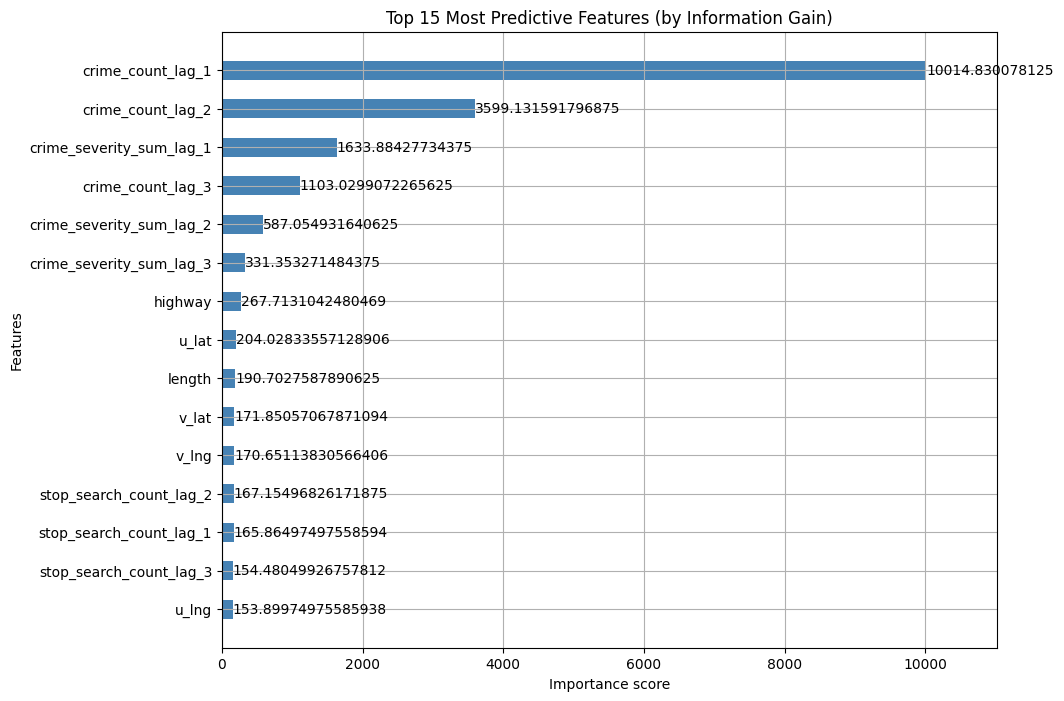


Feature Importance Rankings:
                     Feature          Gain
0          crime_count_lag_1  10014.830078
1          crime_count_lag_2   3599.131592
2   crime_severity_sum_lag_1   1633.884277
3          crime_count_lag_3   1103.029907
4   crime_severity_sum_lag_2    587.054932
5   crime_severity_sum_lag_3    331.353271
6                    highway    267.713104
7                      u_lat    204.028336
8                     length    190.702759
9                      v_lat    171.850571
10                     v_lng    170.651138
11   stop_search_count_lag_2    167.154968
12   stop_search_count_lag_1    165.864975
13   stop_search_count_lag_3    154.480499
14                     u_lng    153.899750


,Feature,Gain
0,crime_count_lag_1,10014.830078
1,crime_count_lag_2,3599.131592
2,crime_severity_sum_lag_1,1633.884277
3,crime_count_lag_3,1103.029907
4,crime_severity_sum_lag_2,587.054932
5,crime_severity_sum_lag_3,331.353271
6,highway,267.713104
7,u_lat,204.028336
8,length,190.702759
9,v_lat,171.850571


In [42]:
feature_importance(model, X_train)

In [43]:
future_edges, future_node = predict_and_map_to_nodes(df_ml, model, X_train, latest_month='2026_05')

Predicting future crime counts...

Top 5 Highest Risk Nodes:
       node_id  node_safety_cost        lat       lng
0   4360605039         11.000000  51.530210 -0.123074
1   1670707917          9.974656  51.539440 -0.142696
2   3943984250          4.470089  51.523291 -0.120597
3   1670708096          3.991787  51.539400 -0.142684
4  13869892513          3.831133  51.521985 -0.109765


In [46]:
osm_tag_mapping(future_edges)

Saved OSM Tag mapping. Use this to tag your .osm.pbf file.
